Atividade 2

Luis Ernani Viniski

Leonardo Barbosa dos Santos

Gabriel Bezerra Carrazzoni

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as sts
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, single, average, fcluster
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

In [ ]:
#Importando os dados
url = "https://raw.githubusercontent.com/devjaynemorais/modelos_descritivos_curso/main/Aula%2002/dados/mall_customers.csv"
df = pd.read_csv(url)

In [ ]:
#Visualizando o dataset
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
#Informações do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
#Estatísticas do Dataset
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
#Verificando se existem linhas duplicadas
df.duplicated().sum()

0

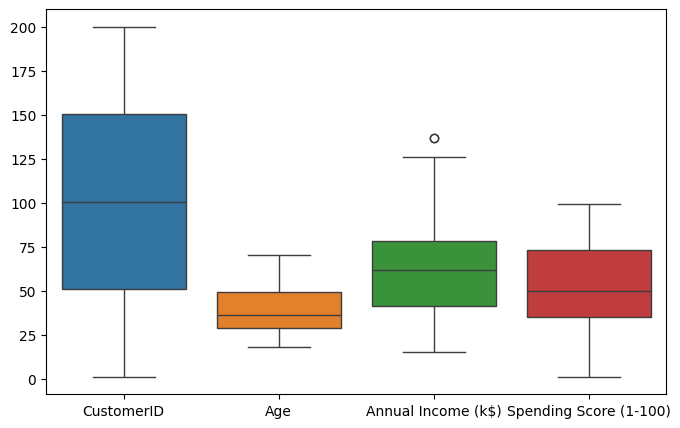

In [ ]:
#Visualisação de outliers
plt.figure(figsize=(8, 5))
sns.boxplot(data=df)
plt.show()

In [ ]:
#Localizando os outliers
df.loc[(df["Annual Income (k$)"] > 126)]

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
198,199,Male,32,137,18
199,200,Male,30,137,83


In [ ]:
#Mediana
mediana = sts.median(df["Annual Income (k$)"])
mediana

61.5

In [ ]:
#Tratando outliers
df.loc[(df["Annual Income (k$)"] > 126),"Annual Income (k$)" ] = mediana

<ipython-input-10-bd24e372cacf>:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '61.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[(df["Annual Income (k$)"] > 126),"Annual Income (k$)" ] = mediana


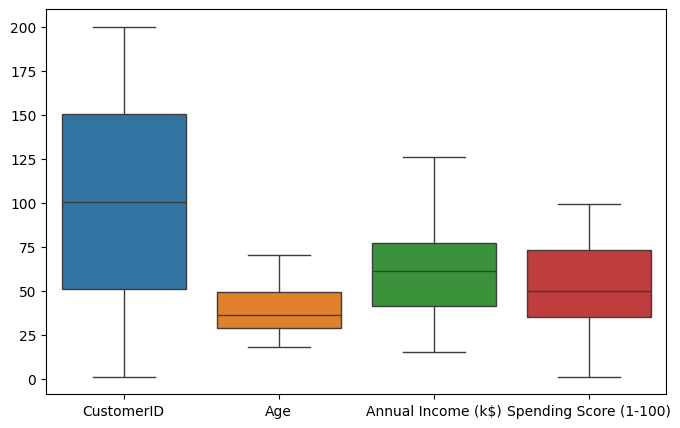

In [ ]:
#Visualizando novamente os dados
plt.figure(figsize=(8, 5))
sns.boxplot(data=df)
plt.show()

In [ ]:
# Codificar o gênero (0 para Masculino, 1 para Feminino)
df["Gender"] = df["Genre"].map({"Male": 0, "Female": 1})

In [ ]:
# Selecionar apenas colunas numéricas
X = df[["Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"]]

In [ ]:
# Normalizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

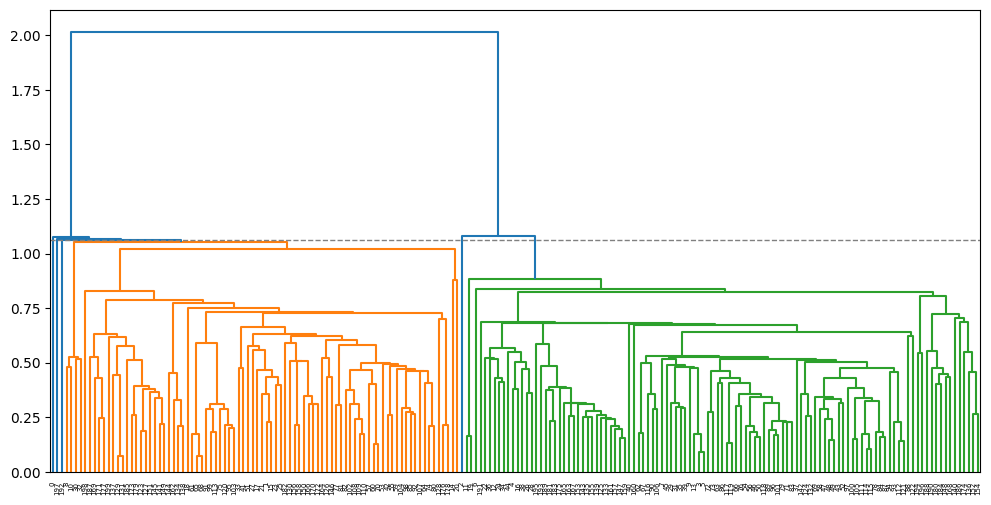

In [ ]:
# Calcula a distancia entre cada amostra
Z = single(X_scaled)
tr = 1.06
#Controla o numero de amostras na plotagem e adiciona linha horizontal
plt.figure(figsize=(12, 6))
dendrogram(Z, color_threshold=tr)
plt.axhline(y=tr, c='grey', lw=1, linestyle='dashed')

plt.show()

In [ ]:
labels = fcluster(Z, t=tr, criterion='distance')

In [ ]:
X['cluster_id'] = labels

<ipython-input-17-e5458726bdc9>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['cluster_id'] = labels


In [ ]:
X

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster_id
0,0,19,15.0,39,4
1,0,21,15.0,81,1
2,1,20,16.0,6,6
3,1,23,16.0,77,5
4,1,31,17.0,40,5
...,...,...,...,...,...
195,1,35,120.0,79,5
196,1,45,126.0,28,5
197,0,32,126.0,74,3
198,0,32,61.5,18,1


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

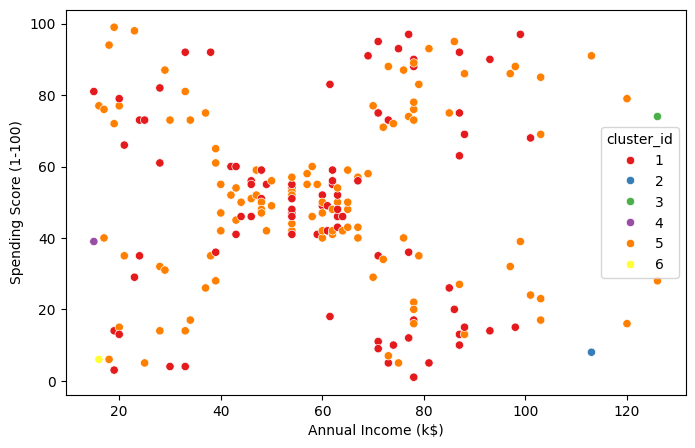

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(X, x="Annual Income (k$)", y="Spending Score (1-100)", hue='cluster_id', palette='Set1')

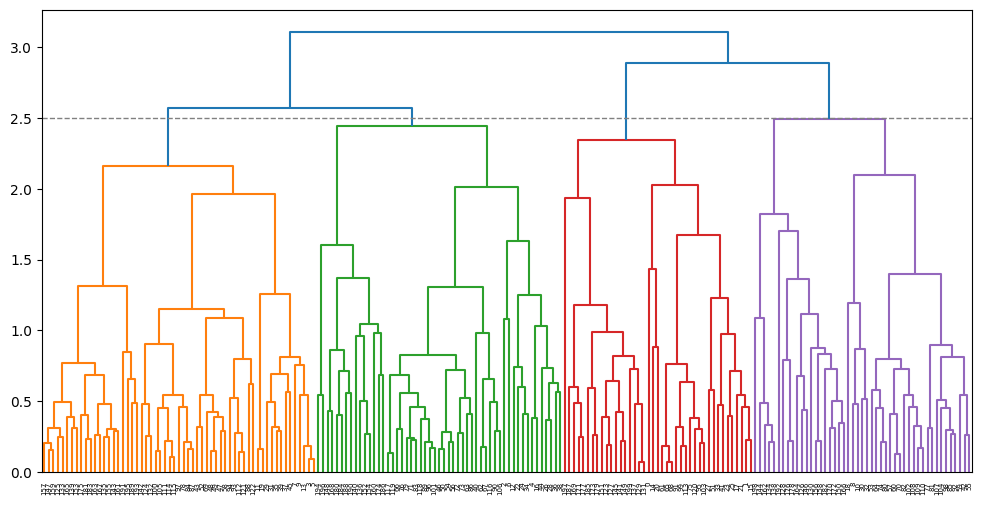

In [ ]:
# Calcula a distancia entre cada amostra
Z = average(X_scaled)
tr = 2.5
#Controla o numero de amostras na plotagem e adiciona linha horizontal
plt.figure(figsize=(12, 6))
dendrogram(Z, color_threshold=tr)
plt.axhline(y=tr, c='grey', lw=1, linestyle='dashed')


plt.show()

In [ ]:
labels = fcluster(Z, t=tr, criterion='distance')

In [ ]:
X['cluster_id'] = labels

<ipython-input-22-e5458726bdc9>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['cluster_id'] = labels


In [ ]:
X

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster_id
0,0,19,15.0,39,3
1,0,21,15.0,81,3
2,1,20,16.0,6,2
3,1,23,16.0,77,1
4,1,31,17.0,40,2
...,...,...,...,...,...
195,1,35,120.0,79,1
196,1,45,126.0,28,2
197,0,32,126.0,74,3
198,0,32,61.5,18,4


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

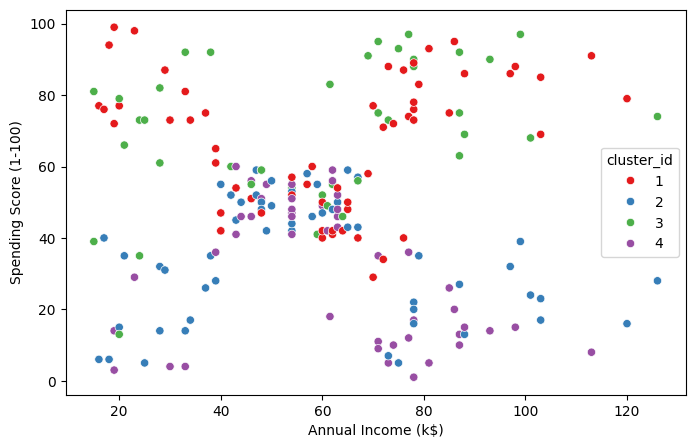

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(X, x="Annual Income (k$)", y="Spending Score (1-100)", hue='cluster_id', palette='Set1')

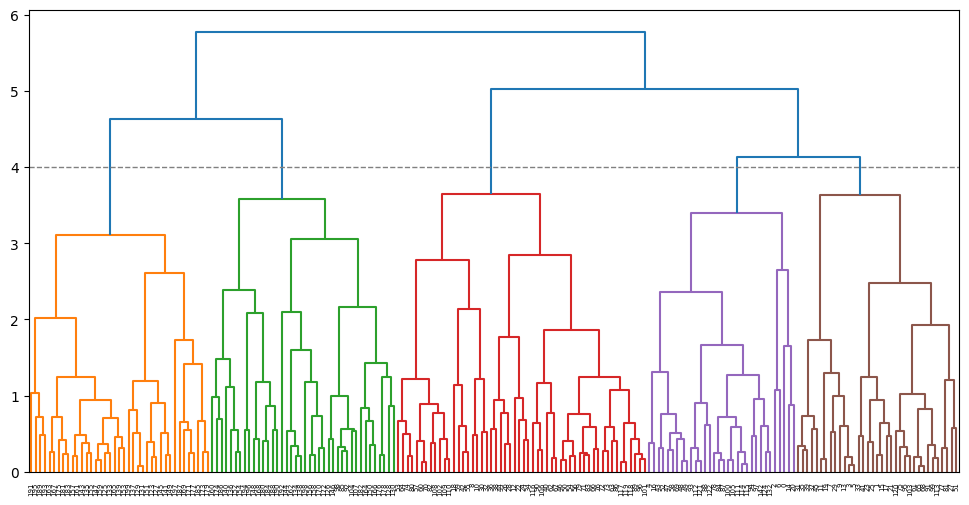

In [ ]:
# Calcula a distancia entre cada amostra
Z = linkage(X_scaled, method='complete', metric='euclidean')
tr = 4
#Controla o numero de amostras na plotagem e adiciona linha horizontal
plt.figure(figsize=(12, 6))
dendrogram(Z, color_threshold=tr)
plt.axhline(y=tr, c='grey', lw=1, linestyle='dashed')

# Show the graph
plt.show()

In [ ]:
labels = fcluster(Z, t=tr, criterion='distance')

In [ ]:
X['cluster_id'] = labels

<ipython-input-27-e5458726bdc9>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['cluster_id'] = labels


In [ ]:
X

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster_id
0,0,19,15.0,39,4
1,0,21,15.0,81,5
2,1,20,16.0,6,4
3,1,23,16.0,77,5
4,1,31,17.0,40,4
...,...,...,...,...,...
195,1,35,120.0,79,1
196,1,45,126.0,28,2
197,0,32,126.0,74,1
198,0,32,61.5,18,2


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

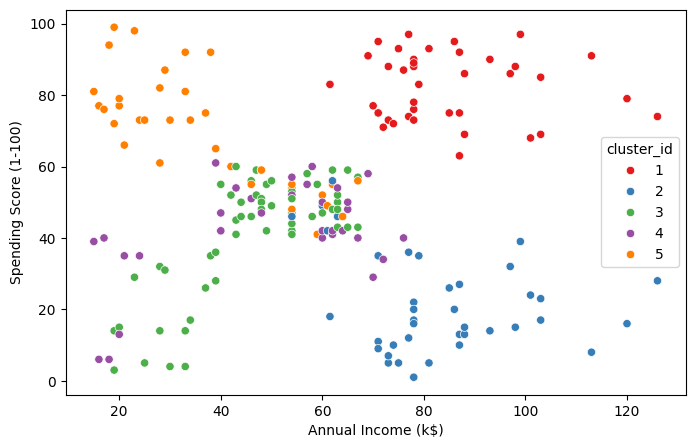

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(X, x="Annual Income (k$)", y="Spending Score (1-100)", hue='cluster_id', palette='Set1')

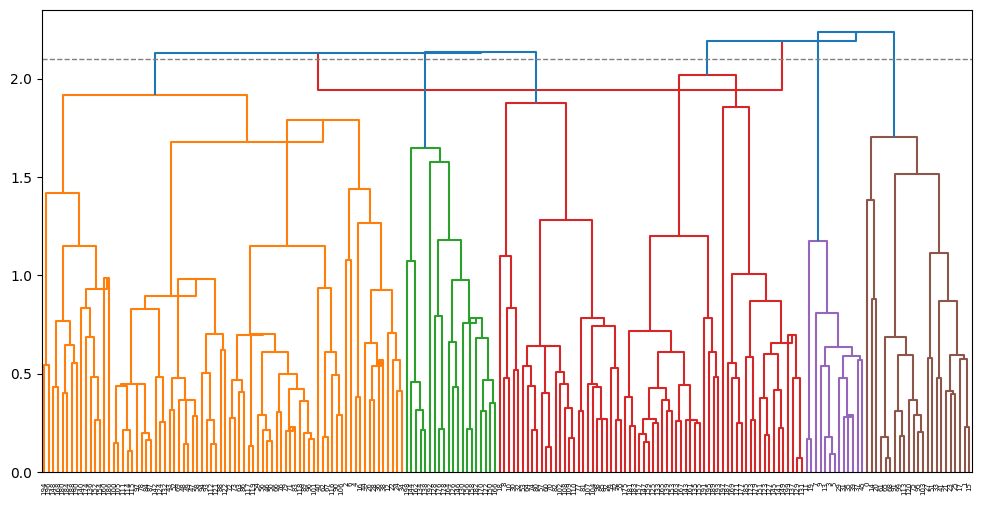

In [ ]:
# Calcula a distancia entre cada amostra
Z = linkage(X_scaled, method='centroid', metric='euclidean')
tr = 2.1
#Controla o numero de amostras na plotagem e adiciona linha horizontal
plt.figure(figsize=(12, 6))
dendrogram(Z, color_threshold=tr)
plt.axhline(y=tr, c='grey', lw=1, linestyle='dashed')

plt.show()

In [ ]:
labels = fcluster(Z, t=tr, criterion='distance')

In [ ]:
X['cluster_id'] = labels

<ipython-input-32-e5458726bdc9>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['cluster_id'] = labels


In [ ]:
X

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster_id
0,0,19,15.0,39,6
1,0,21,15.0,81,6
2,1,20,16.0,6,1
3,1,23,16.0,77,5
4,1,31,17.0,40,1
...,...,...,...,...,...
195,1,35,120.0,79,4
196,1,45,126.0,28,1
197,0,32,126.0,74,4
198,0,32,61.5,18,2


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

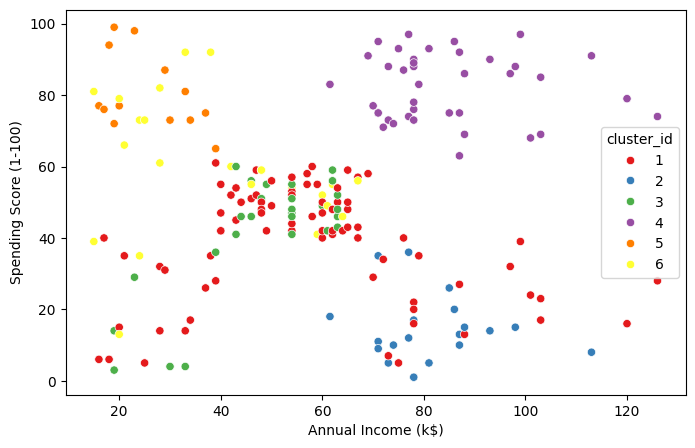

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(X, x="Annual Income (k$)", y="Spending Score (1-100)", hue='cluster_id', palette='Set1')

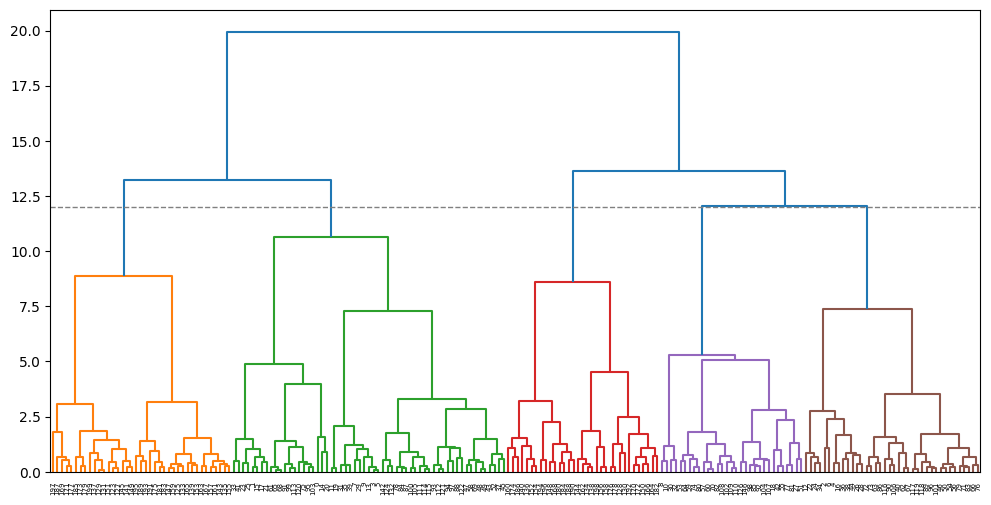

In [ ]:
# Calcula a distancia entre cada amostra
Z = linkage(X_scaled, method='ward', metric='euclidean')
tr = 12
#Controla o numero de amostras na plotagem e adiciona linha horizontal
plt.figure(figsize=(12, 6))
dendrogram(Z, color_threshold=tr)
plt.axhline(y=tr, c='grey', lw=1, linestyle='dashed')

# Show the graph
plt.show()

In [ ]:
labels = fcluster(Z, t=tr, criterion='distance')

In [ ]:
X['cluster_id'] = labels

<ipython-input-37-e5458726bdc9>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['cluster_id'] = labels


In [ ]:
X

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster_id
0,0,19,15.0,39,2
1,0,21,15.0,81,2
2,1,20,16.0,6,5
3,1,23,16.0,77,2
4,1,31,17.0,40,5
...,...,...,...,...,...
195,1,35,120.0,79,1
196,1,45,126.0,28,3
197,0,32,126.0,74,1
198,0,32,61.5,18,3


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

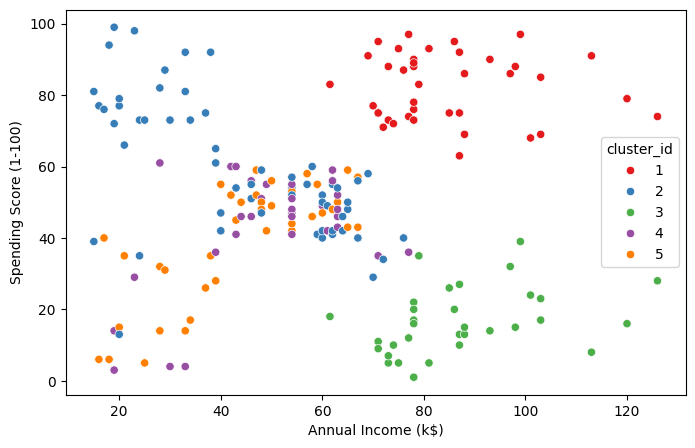

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(X, x="Annual Income (k$)", y="Spending Score (1-100)", hue='cluster_id', palette='Set1')

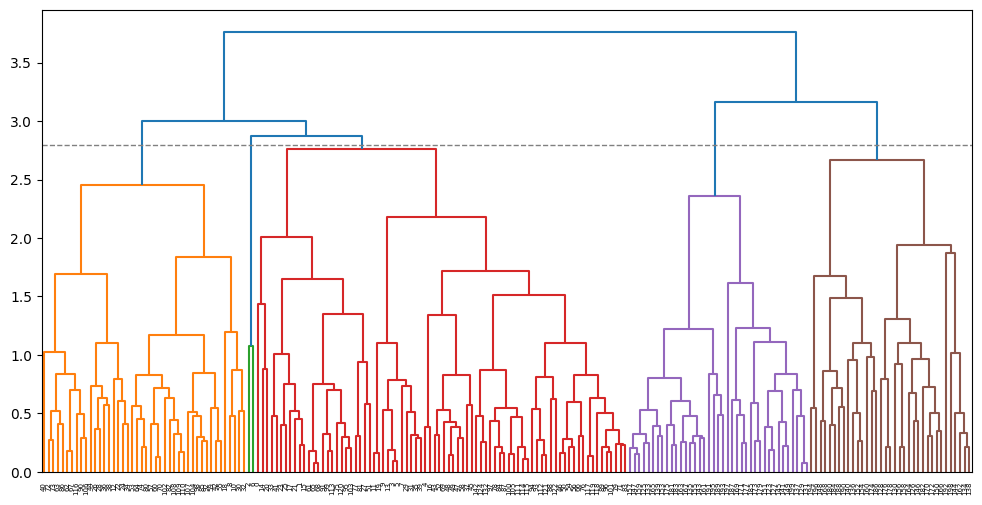

In [ ]:
# Calcula a distancia entre cada amostra
Z = linkage(X_scaled, method='weighted', metric='euclidean')
tr = 2.8
#Controla o numero de amostras na plotagem e adiciona linha horizontal
plt.figure(figsize=(12, 6))
dendrogram(Z, color_threshold=tr)
plt.axhline(y=tr, c='grey', lw=1, linestyle='dashed')

# Show the graph
plt.show()

In [ ]:
labels = fcluster(Z, t=tr, criterion='distance')

In [ ]:
X['cluster_id'] = labels

<ipython-input-42-e5458726bdc9>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['cluster_id'] = labels


In [ ]:
X

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster_id
0,0,19,15.0,39,3
1,0,21,15.0,81,3
2,1,20,16.0,6,2
3,1,23,16.0,77,3
4,1,31,17.0,40,3
...,...,...,...,...,...
195,1,35,120.0,79,4
196,1,45,126.0,28,5
197,0,32,126.0,74,4
198,0,32,61.5,18,5


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

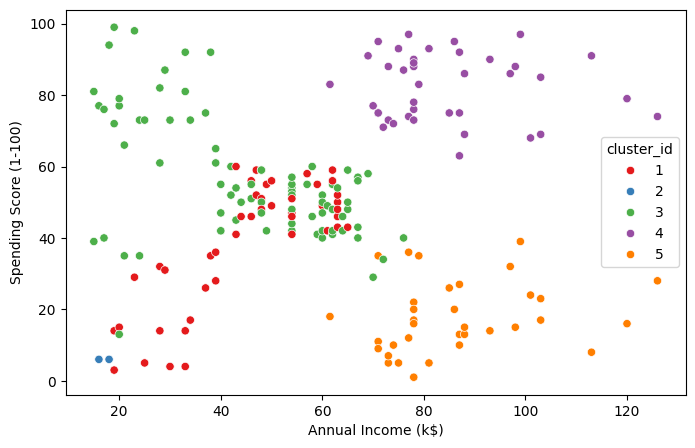

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(X, x="Annual Income (k$)", y="Spending Score (1-100)", hue='cluster_id', palette='Set1')

In [ ]:
#Usando os dados com o linkage: complete
Z = linkage(X_scaled, method='complete', metric='euclidean')
tr = 4
labels = fcluster(Z, t=tr, criterion='distance')
X['cluster_id'] = labels
medias_por_cluster = X.groupby('cluster_id').mean()
medias_por_cluster

<ipython-input-45-e6c2b9642501>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['cluster_id'] = labels


,Gender,Age,Annual Income (k$),Spending Score (1-100)
cluster_id,,,,
1,0.538462,32.692308,84.602564,82.128205
2,0.375000,42.650000,82.812500,21.100000
3,0.629630,55.462963,46.277778,40.851852
4,0.906250,28.468750,48.906250,42.250000
5,0.371429,25.228571,36.714286,69.571429


##**📊 Distribuição dos Clusters e sua Interpretação**
A análise revela cinco clusters distintos, cada um com características marcantes em relação à idade, renda e comportamento de gastos. A interpretação dos grupos permite identificar perfis de clientes e sugerir estratégias adequadas para cada um.

**Cluster 1 (🔴 Vermelho) - Jovens de Alta Renda e Alto Consumo**

💰 Renda Alta | Gastos Elevados | Idade Mediana

Média: 32 anos | Renda: 84.6k | Spending Score: 82.1

🔹 Público jovem com alto poder aquisitivo e grande propensão ao consumo.

🔹 Potencial para produtos premium e experiências exclusivas.

🔹 Estratégia: Fidelização, atendimento VIP e campanhas segmentadas para luxo.

**Cluster 2 (🔵 Azul) - Alta Renda, Mas Gastos Controlados**

💰 Renda Alta | Baixo Spending Score | Predominância Feminina

Média: 42 anos | Renda: 82.8k | Spending Score: 21.1

🔹 Profissionais de meia-idade que gastam de forma mais racional.

🔹 Possivelmente focados em investimentos e compras essenciais.

🔹 Estratégia: Ofertas exclusivas para compras planejadas, descontos progressivos e benefícios para fidelização.

**Cluster 3 (🟢 Verde) - Pessoas Mais Velhas com Renda Média e Gastos Moderados**

📊 Idade Elevada | Renda Média | Gastos Controlados

Média: 55 anos | Renda: 46.2k | Spending Score: 40.8

🔹 Público mais maduro, com gastos equilibrados.

🔹 Provavelmente consumidores fiéis e criteriosos.

🔹 Estratégia: Atendimento personalizado, programas de fidelidade e produtos de qualidade garantida.

**Cluster 4 (🟣 Roxo) - Homens Jovens com Renda Média e Gastos Moderados**

👨 Predominância Masculina | Renda Mediana | Gastos Controlados

Média: 28 anos | Renda: 48.9k | Spending Score: 42.2

🔹 Jovens com potencial de compra, mas ainda sem alto consumo.

🔹 Possível foco em produtos tecnológicos e experiências sociais.

🔹 Estratégia: Promoções segmentadas, cashback e incentivos para aumentar o ticket médio.

**Cluster 5 (🟠 Laranja) - Jovens de Baixa Renda e Alto Consumo**

💸 Baixa Renda | Alto Spending Score | Predominância Feminina

Média: 25 anos | Renda: 36.7k | Spending Score: 69.5

🔹 Consumidores jovens que priorizam experiências e tendências.

🔹 Alto potencial para compras impulsivas e engajamento digital.

🔹 Estratégia: Marketing digital forte, campanhas de influência e gamificação para fidelização.

In [ ]:
K = X.head(40)

In [ ]:
K_scaled = scaler.fit_transform(K)

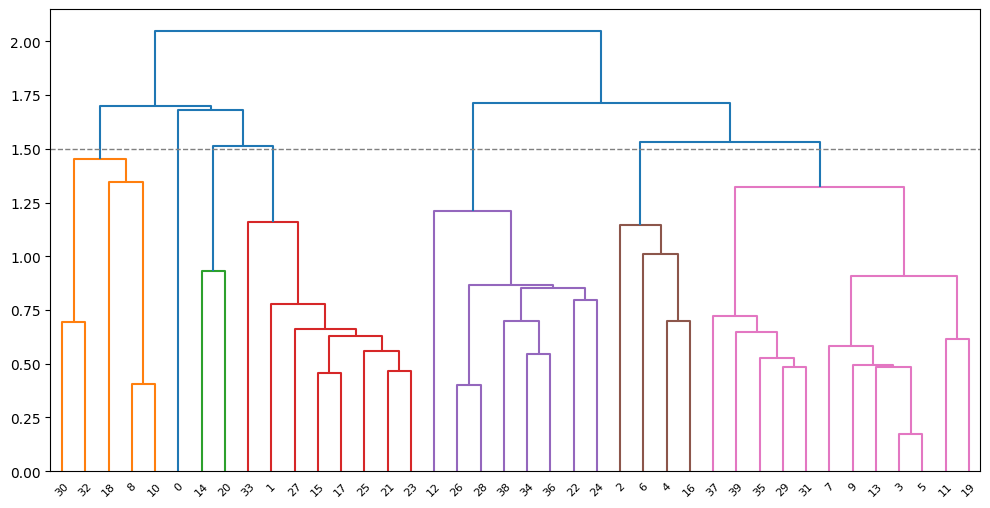

In [ ]:
# Calcula a distancia entre cada amostra
Z = single(K_scaled)
tr = 1.5
#Controla o numero de amostras na plotagem e adiciona linha horizontal
plt.figure(figsize=(12, 6))
dendrogram(Z, color_threshold=tr)
plt.axhline(y=tr, c='grey', lw=1, linestyle='dashed')

# Show the graph
plt.show()

In [ ]:
labels = fcluster(Z, t=tr, criterion='distance')

In [ ]:
K['cluster_id'] = labels

<ipython-input-50-7ef3153406fa>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  K['cluster_id'] = labels


In [ ]:
K.head(10)

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster_id
0,0,19,15.0,39,4
1,0,21,15.0,81,3
2,1,20,16.0,6,6
3,1,23,16.0,77,7
4,1,31,17.0,40,6
5,1,22,17.0,76,7
6,1,35,18.0,6,6
7,1,23,18.0,94,7
8,0,64,19.0,3,1
9,1,30,19.0,72,7


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

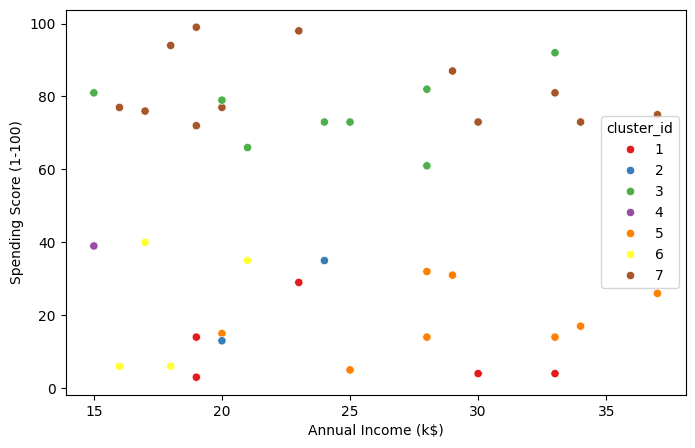

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(K, x="Annual Income (k$)", y="Spending Score (1-100)", hue='cluster_id', palette='Set1')

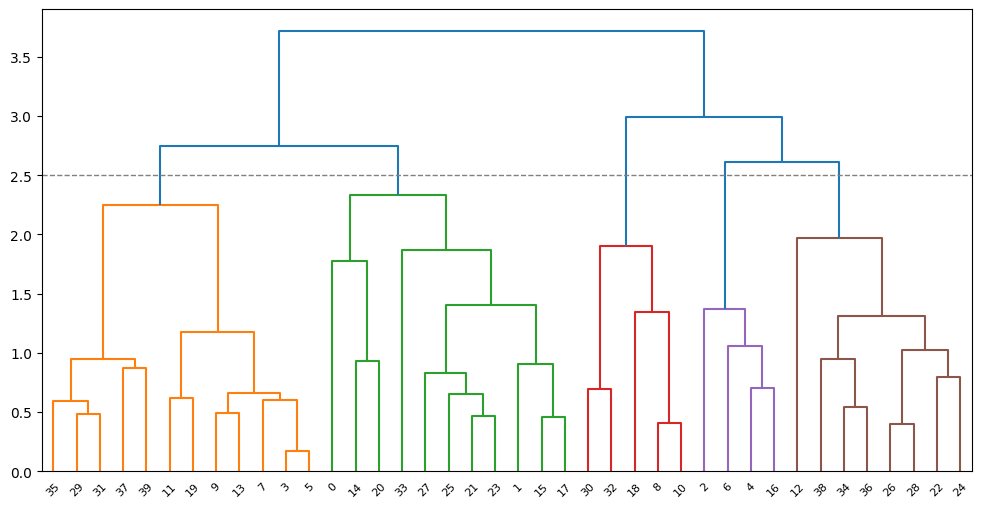

In [ ]:
# Calculate the distance entre cada amostra
Z = average(K_scaled)
tr = 2.5
# Control number of clusters in the plot + add horizontal line.
plt.figure(figsize=(12, 6))
dendrogram(Z, color_threshold=tr)
plt.axhline(y=tr, c='grey', lw=1, linestyle='dashed')

# Show the graph
plt.show()

In [ ]:
labels = fcluster(Z, t=tr, criterion='distance')

In [ ]:
K['cluster_id'] = labels

<ipython-input-55-7ef3153406fa>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  K['cluster_id'] = labels


In [ ]:
K.head(10)

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster_id
0,0,19,15.0,39,2
1,0,21,15.0,81,2
2,1,20,16.0,6,4
3,1,23,16.0,77,1
4,1,31,17.0,40,4
5,1,22,17.0,76,1
6,1,35,18.0,6,4
7,1,23,18.0,94,1
8,0,64,19.0,3,3
9,1,30,19.0,72,1


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

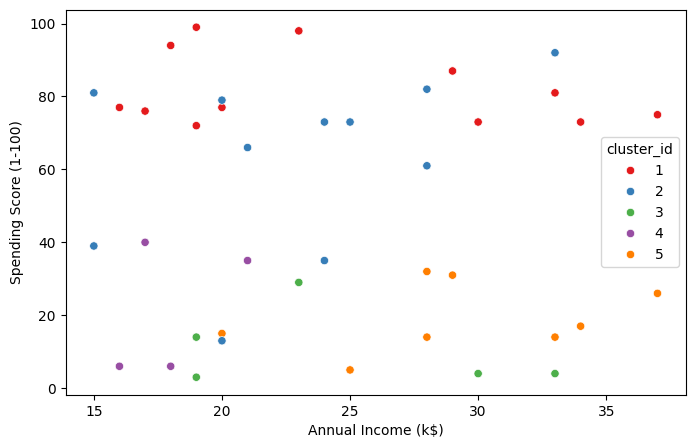

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(K, x="Annual Income (k$)", y="Spending Score (1-100)", hue='cluster_id', palette='Set1')

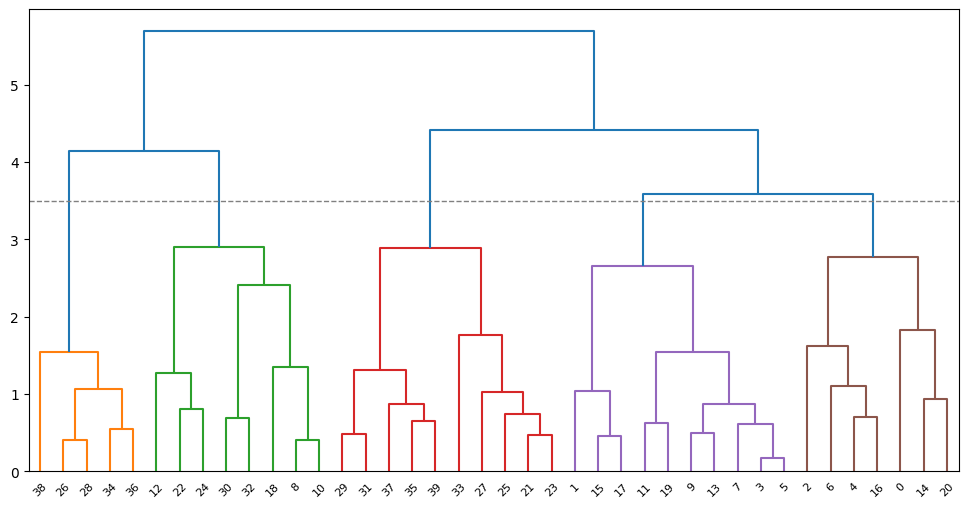

In [ ]:
# Calculate the distance entre cada amostra
Z = linkage(K_scaled, method='complete', metric='euclidean')
tr = 3.5
# Control number of clusters in the plot + add horizontal line.
plt.figure(figsize=(12, 6))
dendrogram(Z, color_threshold=tr)
plt.axhline(y=tr, c='grey', lw=1, linestyle='dashed')

# Show the graph
plt.show()

In [ ]:
labels = fcluster(Z, t=tr, criterion='distance')

In [ ]:
K['cluster_id'] = labels

<ipython-input-60-7ef3153406fa>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  K['cluster_id'] = labels


In [ ]:
K.head(10)

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster_id
0,0,19,15.0,39,5
1,0,21,15.0,81,4
2,1,20,16.0,6,5
3,1,23,16.0,77,4
4,1,31,17.0,40,5
5,1,22,17.0,76,4
6,1,35,18.0,6,5
7,1,23,18.0,94,4
8,0,64,19.0,3,2
9,1,30,19.0,72,4


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

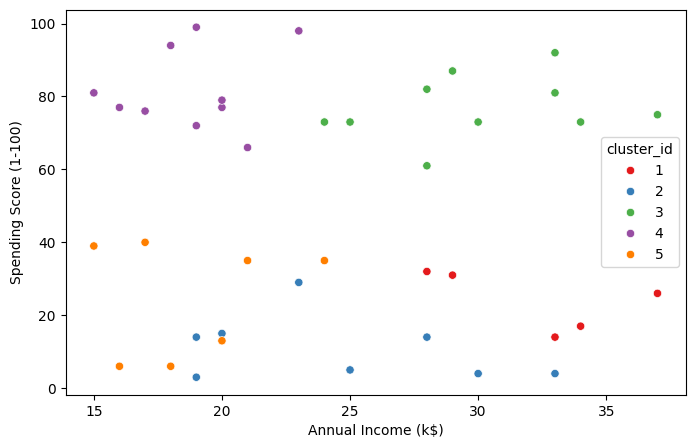

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(K, x="Annual Income (k$)", y="Spending Score (1-100)", hue='cluster_id', palette='Set1')

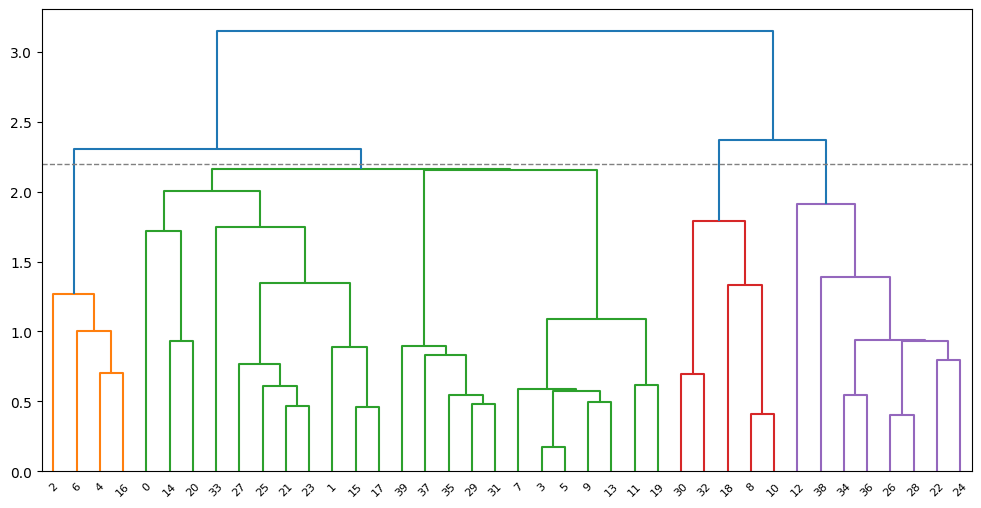

In [ ]:
# Calculate the distance entre cada amostra
Z = linkage(K_scaled, method='centroid', metric='euclidean')
tr = 2.2
# Control number of clusters in the plot + add horizontal line.
plt.figure(figsize=(12, 6))
dendrogram(Z, color_threshold=tr)
plt.axhline(y=tr, c='grey', lw=1, linestyle='dashed')

# Show the graph
plt.show()

In [ ]:
labels = fcluster(Z, t=tr, criterion='distance')

In [ ]:
K['cluster_id'] = labels

<ipython-input-65-7ef3153406fa>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  K['cluster_id'] = labels


In [ ]:
K.head(10)

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster_id
0,0,19,15.0,39,2
1,0,21,15.0,81,2
2,1,20,16.0,6,1
3,1,23,16.0,77,2
4,1,31,17.0,40,1
5,1,22,17.0,76,2
6,1,35,18.0,6,1
7,1,23,18.0,94,2
8,0,64,19.0,3,3
9,1,30,19.0,72,2


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

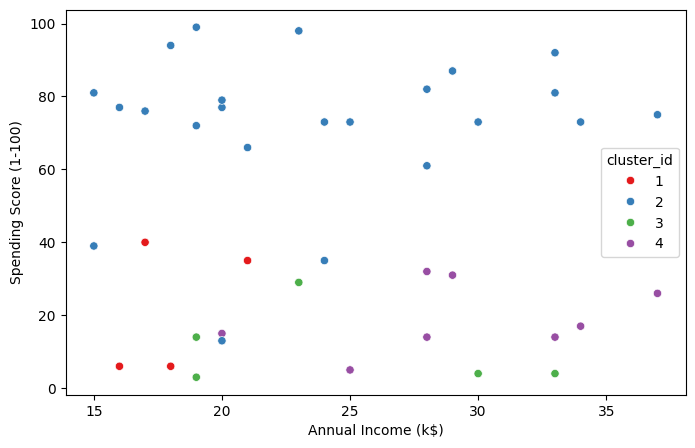

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(K, x="Annual Income (k$)", y="Spending Score (1-100)", hue='cluster_id', palette='Set1')

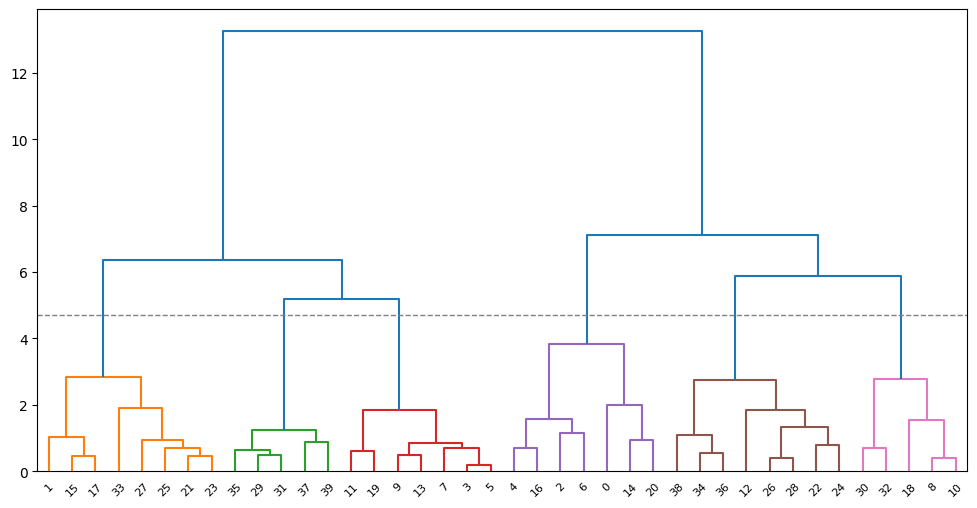

In [ ]:
# Calculate the distance entre cada amostra
Z = linkage(K_scaled, method='ward', metric='euclidean')
tr = 4.7
# Control number of clusters in the plot + add horizontal line.
plt.figure(figsize=(12, 6))
dendrogram(Z, color_threshold=tr)
plt.axhline(y=tr, c='grey', lw=1, linestyle='dashed')

# Show the graph
plt.show()

In [ ]:
labels = fcluster(Z, t=tr, criterion='distance')

In [ ]:
K['cluster_id'] = labels

<ipython-input-70-7ef3153406fa>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  K['cluster_id'] = labels


In [ ]:
K.head(10)

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster_id
0,0,19,15.0,39,4
1,0,21,15.0,81,1
2,1,20,16.0,6,4
3,1,23,16.0,77,3
4,1,31,17.0,40,4
5,1,22,17.0,76,3
6,1,35,18.0,6,4
7,1,23,18.0,94,3
8,0,64,19.0,3,6
9,1,30,19.0,72,3


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

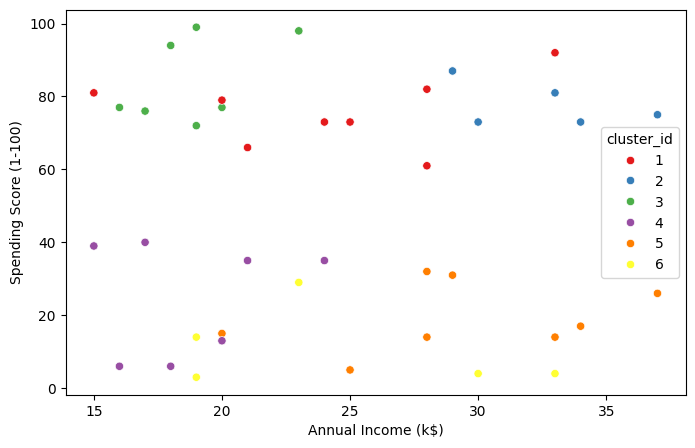

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(K, x="Annual Income (k$)", y="Spending Score (1-100)", hue='cluster_id', palette='Set1')

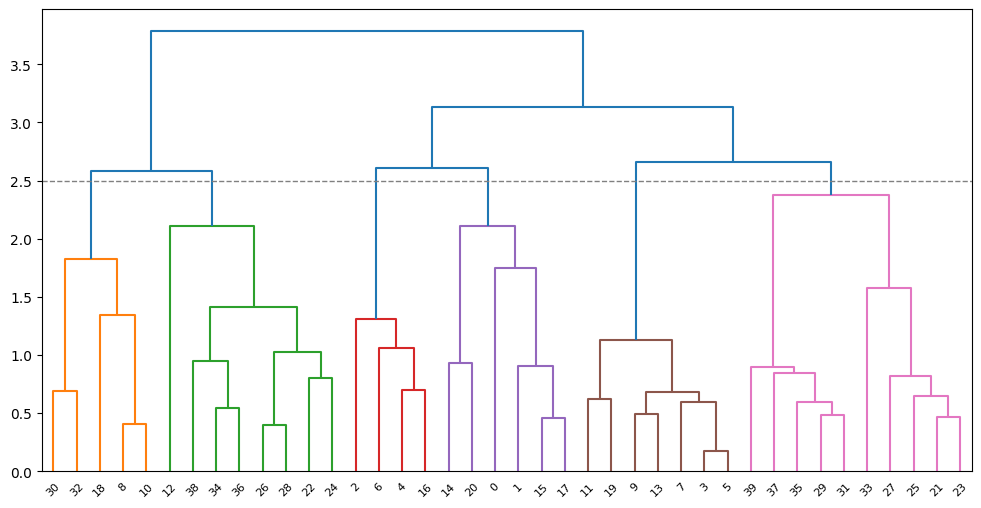

In [ ]:
# Calculate the distance entre cada amostra
Z = linkage(K_scaled, method='weighted', metric='euclidean')
tr = 2.5
# Control number of clusters in the plot + add horizontal line.
plt.figure(figsize=(12, 6))
dendrogram(Z, color_threshold=tr)
plt.axhline(y=tr, c='grey', lw=1, linestyle='dashed')

# Show the graph
plt.show()

In [ ]:
labels = fcluster(Z, t=tr, criterion='distance')

In [ ]:
K['cluster_id'] = labels

<ipython-input-75-7ef3153406fa>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  K['cluster_id'] = labels


In [ ]:
K.head(10)

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster_id
0,0,19,15.0,39,4
1,0,21,15.0,81,4
2,1,20,16.0,6,3
3,1,23,16.0,77,5
4,1,31,17.0,40,3
5,1,22,17.0,76,5
6,1,35,18.0,6,3
7,1,23,18.0,94,5
8,0,64,19.0,3,1
9,1,30,19.0,72,5


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

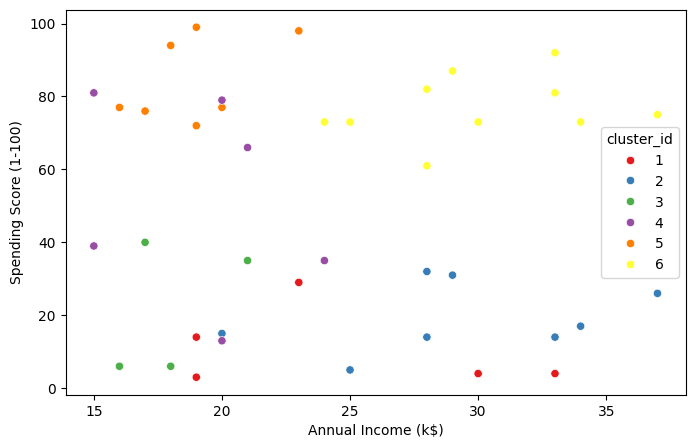

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(K, x="Annual Income (k$)", y="Spending Score (1-100)", hue='cluster_id', palette='Set1')

In [ ]:
#Usando os dados com o linkage: complete
Z = linkage(K_scaled, method='complete', metric='euclidean')
tr = 4
labels = fcluster(Z, t=tr, criterion='distance')
K['cluster_id'] = labels
medias_por_cluster = K.groupby('cluster_id').mean()
medias_por_cluster

<ipython-input-78-2ab0a2ba86b2>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  K['cluster_id'] = labels


,Gender,Age,Annual Income (k$),Spending Score (1-100)
cluster_id,,,,
1,1.000000,42.400000,32.200000,24.000000
2,0.375000,56.750000,24.625000,11.000000
3,0.500000,25.300000,30.100000,77.000000
4,0.647059,27.470588,18.764706,58.411765


##**📊 Distribuição dos Clusters e sua Interpretação**
A análise revela quatro clusters distintos, com variações significativas em idade, renda e hábitos de consumo. A interpretação dos grupos ajuda a entender diferentes perfis de clientes e a direcionar estratégias eficazes para cada um.

**Cluster 1 (🔴 Vermelho) - Homens de Meia-Idade com Renda Baixa e Baixo Consumo**

👨 Predominância Masculina | Meia-Idade | Baixa Renda | Gastos Baixos

Média: 42 anos | Renda: 32.2k | Spending Score: 24.0

🔹 Público masculino de meia-idade, com renda limitada e baixo consumo.

🔹 Provavelmente gastam de forma mais conservadora, priorizando necessidades básicas.

🔹 Estratégia: Ofertas focadas em valor e custo-benefício, programas de desconto para compras recorrentes.


**Cluster 2 (🔵 Azul) - Clientes Mais Velhos, de Baixa Renda e Quase Não Gastam**

👩 Predominância Feminina | Idade Elevada | Baixa Renda | Mínimo Consumo

Média: 56 anos | Renda: 24.6k | Spending Score: 11.0

🔹 Grupo mais velho, de renda baixa e consumo extremamente reduzido.

🔹 Possivelmente aposentados ou pessoas com orçamento restrito.

🔹 Estratégia: Produtos essenciais, planos de pagamento facilitados e descontos para fidelização.


**Cluster 3 (🟢 Verde) - Jovens Adultos com Renda Baixa, Mas Alto Consumo**
📈 Gênero Equilibrado | Jovens | Renda Baixa | Gastam Muito

Média: 25 anos | Renda: 30.1k | Spending Score: 77.0

🔹 Jovens adultos que, apesar da renda mais baixa, são grandes consumidores.

🔹 Possível perfil de compradores impulsivos, interessados em tendências e experiências.

🔹 Estratégia: Marketing digital forte, promoções agressivas e campanhas voltadas para status e exclusividade.

**Cluster 4 (🟣 Roxo) - Jovens de Baixa Renda com Consumo Moderado**
👨 Predominância Masculina | Adultos Jovens | Renda Muito Baixa | Gastos Moderados

Média: 27 anos | Renda: 18.7k | Spending Score: 58.4

🔹 Grupo jovem, de renda muito baixa, mas ainda com uma propensão razoável ao consumo.

🔹 Provavelmente buscam produtos acessíveis e boas ofertas.

🔹 Estratégia: Produtos econômicos, parcelamentos flexíveis e programas de pontos para fidelização.

In [ ]:
# Criar listas para armazenar os scores
cluster_algorithms = {
    "K-Means": KMeans(n_clusters=5, random_state=42),
    "Agglomerative Clustering": AgglomerativeClustering(n_clusters=5),
    "DBSCAN": DBSCAN(eps=1.5, min_samples=5)
}

silhouette_scores = {}

for name, model in cluster_algorithms.items():
    labels = model.fit_predict(X_scaled)
    if len(set(labels)) > 1:  # DBSCAN pode gerar um único cluster (-1)
        silhouette_scores[name] = silhouette_score(X_scaled, labels)
    else:
        silhouette_scores[name] = -1  # Indicar que DBSCAN não conseguiu separar bem os clusters

# Exibir os resultados dos scores
print("\nMétricas de Silhouette Score para diferentes algoritmos:")
for name, score in silhouette_scores.items():
    print(f"{name}: {score:.4f}")

# Escolher o melhor algoritmo (o maior silhouette score)
best_algorithm = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nMelhor algoritmo baseado no silhouette score: {best_algorithm}")


Métricas de Silhouette Score para diferentes algoritmos:
K-Means: 0.2710
Agglomerative Clustering: 0.2848
DBSCAN: 0.2756

Melhor algoritmo baseado no silhouette score: Agglomerative Clustering


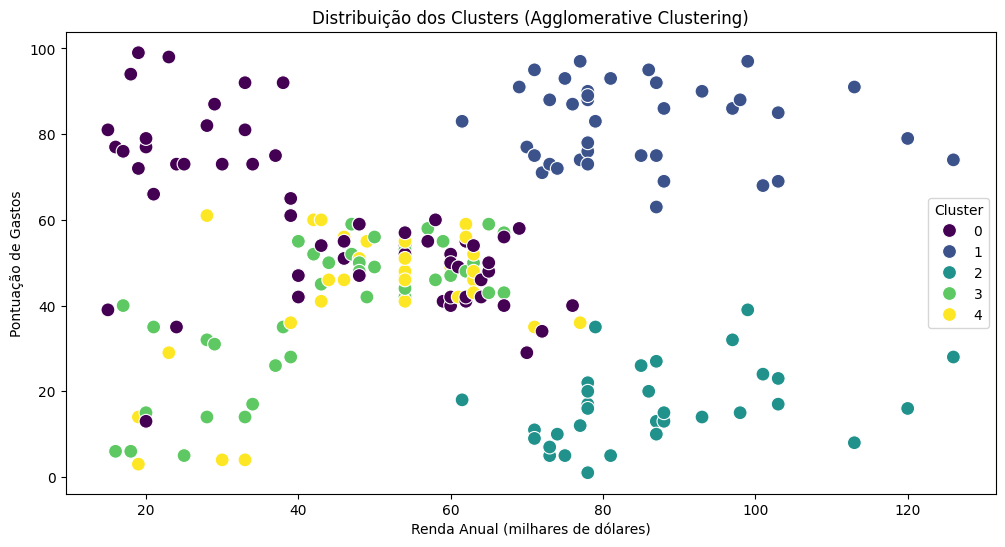


📌 Quantidade de clientes por cluster:
Cluster
0    59
1    39
3    38
2    33
4    31
Name: count, dtype: int64


In [ ]:
# Aplicar Agglomerative Clustering com número de clusters definido com base no dendograma
num_clusters = 5  # Definir o número de clusters
model = AgglomerativeClustering(n_clusters=num_clusters)
df["Cluster"] = model.fit_predict(X_scaled)

# Visualizar a distribuição dos clusters com um scatterplot
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df["Annual Income (k$)"], y=df["Spending Score (1-100)"], hue=df["Cluster"], palette="viridis", s=100)
plt.title("Distribuição dos Clusters (Agglomerative Clustering)")
plt.xlabel("Renda Anual (milhares de dólares)")
plt.ylabel("Pontuação de Gastos")
plt.legend(title="Cluster")
plt.show()


# Contagem de clientes por cluster
print("\n📌 Quantidade de clientes por cluster:")
print(df["Cluster"].value_counts())

-Cluster 0	Clientes de baixa renda e baixo gasto (público econômico).

Cluster 1	Clientes com alta renda e alta pontuação de gastos (grande poder aquisitivo).

Cluster 2	Grupo intermediário, com renda e gastos médios.

Cluster 3	Clientes com baixa renda, mas alto nível de gastos (provável público
impulsivo).

Cluster 4	Clientes com alta renda, mas baixo nível de gastos (conservadores nos gastos).

##CONCLUSÃO


O Agglomerative Clustering foi eficaz em segmentar os clientes em 5 perfis distintos.

O dendograma ajudou a definir o número ideal de clusters.

A análise revelou padrões que podem ser usados para estratégias de marketing direcionadas.